In [ ]:
# Cell 0
!pip install datasets transformers pyarrow -q

In [62]:
# Cell 1
import os, gc, glob, math, time, json, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import GradScaler
from datasets import load_dataset, DatasetDict, ClassLabel, load_from_disk
from transformers import AutoTokenizer, get_cosine_schedule_with_warmup

CONFIG = {
    'input_pattern'       : '/kaggle/input/datasets/bangta205/scam-detection-datasets-preprocessed',
    'cache_dir'           : '/kaggle/working/.cache',
    'tokenized_dir'       : '/kaggle/working/tokenized',
    'output_dir'          : '/kaggle/working/checkpoints',
    'model_name'          : 'vinai/phobert-base',
    'max_length'          : 128,
    'sample_ratio'        : 1 / 8,
    'train_ratio'         : 0.90,
    'val_ratio'           : 0.05,
    'lora_r'              : 16,
    'lora_alpha'          : 32,
    'lora_dropout'        : 0.1,
    'num_meta'            : 3,
    'num_classes'         : 2,
    'batch_size'          : 64,
    'grad_accum'          : 4,
    'epochs'              : 1,
    'lr'                  : 2e-4,
    'weight_decay'        : 1e-2,
    'warmup_ratio'        : 0.06,
    'focal_gamma'         : 2.0,
    'focal_alpha'         : 0.25,
    'num_proc'            : 4,
    'save_every_steps'    : 2000,
    'eval_every_steps'    : 1000,
    'patience'            : 3,
    'seed'                : 42,
}

os.makedirs(CONFIG['cache_dir'],  exist_ok=True)
os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.environ['HF_DATASETS_CACHE'] = CONFIG['cache_dir']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [4]:
# Cell 2
# 1. Load & Kiểm tra phân phối nhãn"
CONFIG['input_pattern'] = CONFIG['input_pattern'].rstrip('/') + '/*.parquet'

files = sorted(glob.glob(CONFIG['input_pattern']))
print(f'Tim thay {len(files)} file parquet')

raw_ds = load_dataset(
    'parquet',
    data_files=files,
    split='train',
    keep_in_memory=False,
)
raw_ds = raw_ds.cast_column('label', ClassLabel(num_classes=2, names=['clean', 'scam']))

n_total    = len(raw_ds)
labels_arr = np.array(raw_ds['label'])
n_0        = int((labels_arr == 0).sum())
n_1        = int((labels_arr == 1).sum())

print(f'Tong ban ghi   : {n_total:,}')
print(f'Nhan 0 (clean) : {n_0:,}  ({n_0/n_total*100:.2f}%)')
print(f'Nhan 1 (scam)  : {n_1:,}  ({n_1/n_total*100:.2f}%)')

Tim thay 35 file parquet


Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/36 [00:00<?, ?it/s]

Casting the dataset:   0%|          | 0/31274236 [00:00<?, ? examples/s]

Tong ban ghi   : 31,274,236
Nhan 0 (clean) : 31,204,577  (99.78%)
Nhan 1 (scam)  : 69,659  (0.22%)


In [6]:
# Cell 3
# 2. Giữ nguyên 100% nhãn 1, chỉ hạ mẫu lớp 0 xuống 1/8
target_n_1 = n_1                                # Giữ lại toàn bộ 69,659 mẫu nhãn 1
target_n_0 = int(n_0 * CONFIG['sample_ratio'])   # Chỉ lấy 1/8 của 31.2 triệu mẫu nhãn 0 (~3.9 triệu mẫu)

rng    = np.random.default_rng(CONFIG['seed'])
idx_0  = np.where(labels_arr == 0)[0]
idx_1  = np.where(labels_arr == 1)[0]

# Bốc ngẫu nhiên lớp 0, lớp 1 giữ nguyên toàn bộ indices
s0     = rng.choice(idx_0, size=target_n_0, replace=False)
s1     = idx_1 # Không dùng rng.choice cho lớp 1, lấy trọn vẹn 100%

idx    = np.sort(np.concatenate([s0, s1]))

sampled = raw_ds.select(idx.tolist())
del raw_ds, labels_arr, idx_0, idx_1, s0, s1, idx
gc.collect()

s_labels = np.array(sampled['label'])
print(f'Sau lay mau thông minh (Giữ 100% Scam): {len(sampled):,}')
print(f'  Nhan 0: {(s_labels==0).sum():,}  ({(s_labels==0).mean()*100:.2f}%)')
print(f'  Nhan 1: {(s_labels==1).sum():,}  ({(s_labels==1).mean()*100:.2f}%)')
del s_labels

Sau lay mau thông minh (Giữ 100% Scam): 3,970,231
  Nhan 0: 3,900,572  (98.25%)
  Nhan 1: 69,659  (1.75%)


In [8]:
# Cell 4
# 3. Chia train / val / test = 90:5:5 có phân tầng để chống học vẹt

# Bước 1: Tách 10% cho tập kiểm tra tổng (Val + Test) và 90% cho Train
train_test_split1 = sampled.train_test_split(
    test_size=CONFIG['val_ratio'] * 2, # 5% + 5% = 10%
    stratify_by_column="label",
    seed=CONFIG['seed']
)

train_ds = train_test_split1["train"]
temp_ds  = train_test_split1["test"]

# Bước 2: Chia đôi 10% tập kiểm tra thành 5% Val và 5% Test độc lập
val_test_split2 = temp_ds.train_test_split(
    test_size=0.5, # Chia đôi tập 10% thành 2 tập 5%
    stratify_by_column="label",
    seed=CONFIG['seed']
)

val_ds  = val_test_split2["train"]
test_ds = val_test_split2["test"]

# Dọn dẹp bộ nhớ RAM Kaggle ngay lập tức
del sampled, temp_ds, train_test_split1, val_test_split2
gc.collect()

# In kết quả kiểm tra tỷ lệ phân tầng để đưa vào báo cáo bài tập lớn
print(f'Train : {len(train_ds):,} | Scam (Nhãn 1): {sum(train_ds["label"]):,} ({sum(train_ds["label"])/len(train_ds)*100:.2f}%)')
print(f'Val   : {len(val_ds):,} | Scam (Nhãn 1): {sum(val_ds["label"]):,} ({sum(val_ds["label"])/len(val_ds)*100:.2f}%)')
print(f'Test  : {len(test_ds):,} | Scam (Nhãn 1): {sum(test_ds["label"]):,} ({sum(test_ds["label"])/len(test_ds)*100:.2f}%)')

Train : 3,573,207 | Scam (Nhãn 1): 62,693 (1.75%)
Val   : 198,512 | Scam (Nhãn 1): 3,483 (1.75%)
Test  : 198,512 | Scam (Nhãn 1): 3,483 (1.75%)


In [9]:
# Cell 5
# 4. Tokenize & Luu xuong dia (xoa dan de tranh tran disk)
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

# Normalize n_subscribers theo log tren tap train
max_subs = float(max(train_ds['n_subscribers']) or 1)

REMOVE_COLS = ['cleaned_text', 'has_url', 'verified', 'n_subscribers']

def tokenize_fn(batch):
    enc = tokenizer(
        batch['cleaned_text'],
        max_length=CONFIG['max_length'],
        padding='max_length',
        truncation=True,
    )
    meta = [
        [float(h), float(v), math.log1p(n) / math.log1p(max_subs)]
        for h, v, n in zip(batch['has_url'], batch['verified'], batch['n_subscribers'])
    ]
    return {
        'input_ids'     : enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'metadata'      : meta,
        'label'         : batch['label'],
    }

def process_and_save(ds, name, save_path):
    ds = ds.map(
        tokenize_fn,
        batched=True,
        batch_size=50_000,
        num_proc=CONFIG['num_proc'],
        remove_columns=REMOVE_COLS,
        desc=f'Tokenize {name}',
    )
    ds.save_to_disk(save_path)
    print(f'Da luu {name}: {save_path}  ({len(ds):,} dong)')
    return ds

tok_train = process_and_save(train_ds, 'train', CONFIG['tokenized_dir'] + '/train')
del train_ds; gc.collect()

tok_val   = process_and_save(val_ds,   'val',   CONFIG['tokenized_dir'] + '/val')
del val_ds;   gc.collect()

tok_test  = process_and_save(test_ds,  'test',  CONFIG['tokenized_dir'] + '/test')
del test_ds;  gc.collect()

del tok_train, tok_val, tok_test
gc.collect()
print('Tokenize xong. Du lieu da luu, bo nho da giai phong.')

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenize train (num_proc=4):   0%|          | 0/3573207 [00:00<?, ? examples/s]

...

Saving the dataset (0/1 shards):   0%|          | 0/198512 [00:00<?, ? examples/s]

Da luu val: /kaggle/working/tokenized/val  (198,512 dong)


Tokenize test (num_proc=4):   0%|          | 0/198512 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/198512 [00:00<?, ? examples/s]

Da luu test: /kaggle/working/tokenized/test  (198,512 dong)
Tokenize xong. Du lieu da luu, bo nho da giai phong.


In [22]:
assets_dir = "/kaggle/working/tokenizer_config"
zip_output_dir = "/kaggle/working"
os.makedirs(assets_dir, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
cached_files = tokenizer.save_vocabulary(assets_dir)
tokenizer.save_pretrained(assets_dir)

shutil.make_archive(
    base_name=os.path.join(zip_output_dir, 'tokenizer_config'),
    format='zip',
    root_dir=assets_dir
)

shutil.rmtree(assets_dir)

print("Hoan thanh")


Hoan thanh


In [20]:
from datasets import load_from_disk, DatasetDict

tokenized_dataset = DatasetDict({
    'train': load_from_disk("/kaggle/working/tokenized/train"),
    'validation': load_from_disk("/kaggle/working/tokenized/val"),
    'test': load_from_disk("/kaggle/working/tokenized/test")
})

# In ra danh sách tên tất cả các cột của tập train
print("Tên các cột dữ liệu:", tokenized_dataset['train'].column_names)

# Đếm tổng số lượng cột dữ liệu của tập train
print("Tổng số lượng cột:", len(tokenized_dataset['train'].column_names))

# Xem cấu trúc chi tiết và kiểu dữ liệu của từng tập
print(tokenized_dataset)


Tên các cột dữ liệu: ['label', 'input_ids', 'attention_mask', 'metadata']
Tổng số lượng cột: 4
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask', 'metadata'],
        num_rows: 3573207
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask', 'metadata'],
        num_rows: 198512
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask', 'metadata'],
        num_rows: 198512
    })
})


In [23]:
# --- Set folder path ---
source_dir = '/kaggle/working/tokenized'
output_zip = '/kaggle/working/tokenized'

# --- Compress folder ---
shutil.make_archive(output_zip, 'zip', source_dir)
print("Done")

Done


In [3]:
# Thu muc nguon tu input
INPUT_DIR = "/kaggle/working/tokenized"
# Thu muc dich den working
WORKING_DIR = "/kaggle/working/tokenized"

# Tien hanh sao chep
if os.path.exists(INPUT_DIR):
    if os.path.exists(WORKING_DIR):
        # Xoa neu trung folder
        shutil.rmtree(WORKING_DIR)
    # Copy nguyen folder sang
    shutil.copytree(INPUT_DIR, WORKING_DIR)
    print("Copy data thanh cong")
else:
    print("Khong tim thay nguon")

Copy data thanh cong


In [34]:
# Cell 6
# Hyperparams cua vinai/phobert-base
class PhoBertConfig:
    vocab_size              = 64001
    hidden_size             = 768
    num_layers              = 12
    num_heads               = 12
    intermediate_size       = 3072
    max_position_embeddings = 258
    type_vocab_size         = 1
    hidden_dropout          = 0.1
    attention_dropout       = 0.1
    layer_norm_eps          = 1e-5
    pad_token_id            = 1

PBCFG = PhoBertConfig()


class PhoBertEmbeddings(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.word_emb   = nn.Embedding(c.vocab_size, c.hidden_size, padding_idx=c.pad_token_id)
        self.pos_emb    = nn.Embedding(c.max_position_embeddings, c.hidden_size)
        self.type_emb   = nn.Embedding(c.type_vocab_size, c.hidden_size)
        self.layer_norm = nn.LayerNorm(c.hidden_size, eps=c.layer_norm_eps)
        self.dropout    = nn.Dropout(c.hidden_dropout)
        self.register_buffer('pos_ids', torch.arange(c.max_position_embeddings).unsqueeze(0))

    def forward(self, input_ids, token_type_ids=None):
        B, L    = input_ids.shape
        pos     = self.pos_ids[:, :L]
        ttids   = torch.zeros_like(input_ids) if token_type_ids is None else token_type_ids
        x       = self.word_emb(input_ids) + self.pos_emb(pos) + self.type_emb(ttids)
        return self.dropout(self.layer_norm(x))


class PhoBertSelfAttention(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.num_heads = c.num_heads
        self.head_dim  = c.hidden_size // c.num_heads
        self.q         = nn.Linear(c.hidden_size, c.hidden_size)
        self.k         = nn.Linear(c.hidden_size, c.hidden_size)
        self.v         = nn.Linear(c.hidden_size, c.hidden_size)
        self.attn_drop = nn.Dropout(c.attention_dropout)

    def split_heads(self, x):
        B, L, _ = x.shape
        return x.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)

    def forward(self, x, mask=None):
        Q, K, V = self.split_heads(self.q(x)), self.split_heads(self.k(x)), self.split_heads(self.v(x))
        sc      = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(self.head_dim)
        if mask is not None:
            sc = sc + mask
        w   = self.attn_drop(torch.softmax(sc, dim=-1))
        out = torch.matmul(w, V)
        B, H, L, D = out.shape
        return out.transpose(1, 2).contiguous().view(B, L, H * D)


class PhoBertSelfOutput(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.dense      = nn.Linear(c.hidden_size, c.hidden_size)
        self.layer_norm = nn.LayerNorm(c.hidden_size, eps=c.layer_norm_eps)
        self.dropout    = nn.Dropout(c.hidden_dropout)

    def forward(self, x, residual):
        return self.layer_norm(self.dropout(self.dense(x)) + residual)


class PhoBertAttention(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.self_attn = PhoBertSelfAttention(c)
        self.output    = PhoBertSelfOutput(c)

    def forward(self, x, mask=None):
        return self.output(self.self_attn(x, mask), x)


class PhoBertIntermediate(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.dense = nn.Linear(c.hidden_size, c.intermediate_size)

    def forward(self, x):
        return F.gelu(self.dense(x))


class PhoBertLayerOutput(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.dense      = nn.Linear(c.intermediate_size, c.hidden_size)
        self.layer_norm = nn.LayerNorm(c.hidden_size, eps=c.layer_norm_eps)
        self.dropout    = nn.Dropout(c.hidden_dropout)

    def forward(self, x, residual):
        return self.layer_norm(self.dropout(self.dense(x)) + residual)


class PhoBertLayer(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.attention    = PhoBertAttention(c)
        self.intermediate = PhoBertIntermediate(c)
        self.out          = PhoBertLayerOutput(c)

    def forward(self, x, mask=None):
        a = self.attention(x, mask)
        return self.out(self.intermediate(a), a)


class PhoBertEncoder(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.layers = nn.ModuleList([PhoBertLayer(c) for _ in range(c.num_layers)])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x


class PhoBertPooler(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.dense = nn.Linear(c.hidden_size, c.hidden_size)

    def forward(self, x):
        return torch.tanh(self.dense(x[:, 0]))


class PhoBertModel(nn.Module):
    def __init__(self, cfg=PBCFG):
        super().__init__()
        self.embeddings = PhoBertEmbeddings(cfg)
        self.encoder    = PhoBertEncoder(cfg)
        self.pooler     = PhoBertPooler(cfg)

    def _extend_mask(self, mask):
        return (1.0 - mask.float().unsqueeze(1).unsqueeze(2)) * -10000.0

    def forward(self, input_ids, attention_mask=None):
        m = self._extend_mask(attention_mask) if attention_mask is not None else None
        h = self.embeddings(input_ids)
        h = self.encoder(h, m)
        return h, self.pooler(h)

    def load_hf_weights(self, model_name):
        from transformers import AutoModel
        hf_sd = AutoModel.from_pretrained(model_name).state_dict()
        N = PBCFG.num_layers

        # Tự động dò tìm và khớp tên (Dynamic Key Mapping) dựa trên đặc trưng chuỗi
        new_sd = {}
        for hf_key, hf_tensor in hf_sd.items():
            # 1. Khớp phần Embeddings
            if "embeddings.word_embeddings.weight" in hf_key:    new_sd["embeddings.word_emb.weight"] = hf_tensor
            elif "embeddings.position_embeddings.weight" in hf_key: new_sd["embeddings.pos_emb.weight"] = hf_tensor
            elif "embeddings.token_type_embeddings.weight" in hf_key: new_sd["embeddings.type_emb.weight"] = hf_tensor
            elif "embeddings.LayerNorm.weight" in hf_key:        new_sd["embeddings.layer_norm.weight"] = hf_tensor
            elif "embeddings.LayerNorm.bias" in hf_key:          new_sd["embeddings.layer_norm.bias"] = hf_tensor
            elif "embeddings.position_ids" in hf_key:            new_sd["embeddings.pos_ids"] = hf_tensor
            
            # 2. Khớp phần Pooler cuối cùng
            elif "pooler.dense.weight" in hf_key:                new_sd["pooler.dense.weight"] = hf_tensor
            elif "pooler.dense.bias" in hf_key:                  new_sd["pooler.dense.bias"] = hf_tensor
            
            # 3. Khớp phần các tầng Encoder bằng cách bốc tách chỉ số tầng (layer index)
            elif "encoder.layer." in hf_key:
                # Trích xuất số tầng từ chuỗi (ví dụ: 'roberta.encoder.layer.5.attention...')
                parts = hf_key.split('.')
                layer_idx = int(parts[parts.index('layer') + 1])
                
                if layer_idx < N:
                    my_prefix = f"encoder.layers.{layer_idx}"
                    
                    # QKV Attention
                    if ".attention.self.query.weight" in hf_key:  new_sd[f"{my_prefix}.attention.self_attn.q.weight"] = hf_tensor
                    elif ".attention.self.query.bias" in hf_key:   new_sd[f"{my_prefix}.attention.self_attn.q.bias"] = hf_tensor
                    elif ".attention.self.key.weight" in hf_key:    new_sd[f"{my_prefix}.attention.self_attn.k.weight"] = hf_tensor
                    elif ".attention.self.key.bias" in hf_key:     new_sd[f"{my_prefix}.attention.self_attn.k.bias"] = hf_tensor
                    elif ".attention.self.value.weight" in hf_key:  new_sd[f"{my_prefix}.attention.self_attn.v.weight"] = hf_tensor
                    elif ".attention.self.value.bias" in hf_key:   new_sd[f"{my_prefix}.attention.self_attn.v.bias"] = hf_tensor
                    
                    # Attention Output
                    elif ".attention.output.dense.weight" in hf_key:      new_sd[f"{my_prefix}.attention.output.dense.weight"] = hf_tensor
                    elif ".attention.output.dense.bias" in hf_key:        new_sd[f"{my_prefix}.attention.output.dense.bias"] = hf_tensor
                    elif ".attention.output.LayerNorm.weight" in hf_key:  new_sd[f"{my_prefix}.attention.output.layer_norm.weight"] = hf_tensor
                    elif ".attention.output.LayerNorm.bias" in hf_key:    new_sd[f"{my_prefix}.attention.output.layer_norm.bias"] = hf_tensor
                    
                    # Intermediate và Output
                    elif ".intermediate.dense.weight" in hf_key:          new_sd[f"{my_prefix}.intermediate.dense.weight"] = hf_tensor
                    elif ".intermediate.dense.bias" in hf_key:            new_sd[f"{my_prefix}.intermediate.dense.bias"] = hf_tensor
                    elif ".output.dense.weight" in hf_key:                new_sd[f"{my_prefix}.out.dense.weight"] = hf_tensor
                    elif ".output.dense.bias" in hf_key:                  new_sd[f"{my_prefix}.out.dense.bias"] = hf_tensor
                    elif ".output.LayerNorm.weight" in hf_key:            new_sd[f"{my_prefix}.out.layer_norm.weight"] = hf_tensor
                    elif ".output.LayerNorm.bias" in hf_key:              new_sd[f"{my_prefix}.out.layer_norm.bias"] = hf_tensor

        # Tiến hành nạp đè state_dict đã map chuẩn hóa
        miss, unexp = self.load_state_dict(new_sd, strict=False)
        print(f'PhoBERT weights loaded | missing={miss} | unexpected={unexp}')
        del hf_sd, new_sd; gc.collect()

print('PhoBertModel defined OK')

PhoBertModel defined OK


In [35]:
# Cell 7
# 6. LoRA tu xay dung"
class LoRALinear(nn.Module):
    def __init__(self, linear: nn.Linear, r: int, alpha: int, dropout: float = 0.0):
        super().__init__()
        self.original = linear
        self.r        = r
        self.scaling  = alpha / r
        self.merged   = False

        # Dong bang trong goc
        for p in self.original.parameters():
            p.requires_grad = False

        in_f  = linear.in_features
        out_f = linear.out_features
        # Khoi tao: A ~ N(0,1)/sqrt(r),  B = 0  (dau train delta=0)
        self.lora_A   = nn.Parameter(torch.randn(r, in_f) / math.sqrt(r))
        self.lora_B   = nn.Parameter(torch.zeros(out_f, r))
        self.dropout  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        base  = self.original(x)
        if self.merged:
            return base
        delta = F.linear(self.dropout(x), self.lora_B @ self.lora_A) * self.scaling
        return base + delta

    def merge(self):
        if not self.merged:
            with torch.no_grad():
                self.original.weight.data += (self.lora_B @ self.lora_A) * self.scaling
            self.merged = True


def inject_lora(phobert: PhoBertModel, r: int, alpha: int, dropout: float):
    for i in range(PBCFG.num_layers):
        sa = phobert.encoder.layers[i].attention.self_attn
        sa.q = LoRALinear(sa.q, r, alpha, dropout)
        sa.v = LoRALinear(sa.v, r, alpha, dropout)
    print(f'Injected LoRA (r={r}, alpha={alpha}) vao Q, V cua {PBCFG.num_layers} layers')


def merge_lora(phobert: PhoBertModel):
    merged = 0
    for i in range(PBCFG.num_layers):
        sa = phobert.encoder.layers[i].attention.self_attn
        for proj in [sa.q, sa.v]:
            if isinstance(proj, LoRALinear):
                proj.merge()
                merged += 1
    print(f'Merged {merged} LoRA layers vao PhoBERT')


def trainable_params(model):
    total  = sum(p.numel() for p in model.parameters())
    train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - train
    print(f'Trainable: {train:,} / Total: {total:,} ({train/total*100:.2f}%)')
    print(f'Frozen   : {frozen:,}')

print('LoRA defined OK')

LoRA defined OK


In [38]:
# Cell 8
# 7. ScamClassifier + FocalLoss"
class ScamClassifier(nn.Module):
    def __init__(self, cfg=CONFIG):
        super().__init__()
        H = PBCFG.hidden_size  # 768

        # PhoBERT backbone
        self.encoder = PhoBertModel()
        self.encoder.load_hf_weights(cfg['model_name'])

        # Dong bang toan bo PhoBERT
        for p in self.encoder.parameters():
            p.requires_grad = False

        # Tiem LoRA vao Q va V
        inject_lora(self.encoder, cfg['lora_r'], cfg['lora_alpha'], cfg['lora_dropout'])

        # Nhanh xu ly metadata (has_url, verified, n_subs_norm)
        self.meta_proj = nn.Sequential(
            nn.Linear(cfg['num_meta'], 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
        )

        # Dau phan loai
        self.head = nn.Sequential(
            nn.Linear(H + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, cfg['num_classes']),
        )

    def forward(self, input_ids, attention_mask, metadata):
        _, cls = self.encoder(input_ids, attention_mask)   # (B, 768)
        meta   = self.meta_proj(metadata)                  # (B, 32)
        return self.head(torch.cat([cls, meta], dim=-1))   # (B, 2)


class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, alpha: float = 0.75):
        super().__init__()
        self.gamma = gamma
        # alpha là trọng số cho lớp hiếm (Scam), 1-alpha cho lớp đa số (Clean)
        # Với alpha = 0.75 -> Lớp 0 (Clean) nhận 0.25, Lớp 1 (Scam) nhận 0.75 (Phạt nặng lỗi bỏ sót scam)
        self.register_buffer('alpha_w', torch.tensor([1.0 - alpha, alpha], dtype=torch.float32))

    def forward(self, logits, targets):
        # Tính toán an toàn bằng log_softmax trực tiếp trên GPU để CHỐNG LỖI NaN LOSS
        log_probs = F.log_softmax(logits, dim=-1)
        
        # Lấy log_prob của các nhãn mục tiêu thực tế
        logpt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = torch.exp(logpt) # Xác suất an toàn ổn định số học
        
        # Tính toán thành phần Cross Entropy
        ce_loss = -logpt
        
        # Lấy trọng số alpha tương ứng với từng mẫu trong batch
        at = self.alpha_w[targets]
        
        # Công thức Focal Loss hoàn chỉnh
        loss = at * ((1.0 - pt) ** self.gamma) * ce_loss
        return loss.mean()

print('ScamClassifier + FocalLoss defined OK')

ScamClassifier + FocalLoss defined OK


In [19]:
# Cell 9
# 8. Dataset & DataLoader")
class ArrowDataset(Dataset):
    def __init__(self, hf_ds):
        hf_ds.set_format('torch')
        self.ds = hf_ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        row = self.ds[idx]
        return {
            'input_ids'     : row['input_ids'].long(),
            'attention_mask': row['attention_mask'].long(),
            'metadata'      : row['metadata'].float(),
            'label'         : row['label'].long(),
        }


def build_loaders():
    train_ds_loaded = load_from_disk(CONFIG['tokenized_dir'] + '/train')
    val_ds_loaded   = load_from_disk(CONFIG['tokenized_dir'] + '/val')
    test_ds_loaded  = load_from_disk(CONFIG['tokenized_dir'] + '/test')
    
    train_loader = DataLoader(
        ArrowDataset(train_ds_loaded),
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )
    val_loader = DataLoader(
        ArrowDataset(val_ds_loaded),
        batch_size=CONFIG['batch_size'] * 2,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )
    test_loader = DataLoader(
        ArrowDataset(test_ds_loaded),
        batch_size=CONFIG['batch_size'] * 2,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )
    return train_loader, val_loader, test_loader


# Chạy hàm dựng loader
train_loader, val_loader, test_loader = build_loaders()
print(f'Train batches: {len(train_loader):,}')
print(f'Val   batches: {len(val_loader):,}')
print(f'Test  batches: {len(test_loader):,}')

Train batches: 55,832
Val   batches: 1,551
Test  batches: 1,551


In [39]:
# Cell 10
# 9. Khoi tao Model, Optimizer, Scheduler, Checkpoint
model     = ScamClassifier(CONFIG).to(device)
criterion = FocalLoss(CONFIG['focal_gamma'], CONFIG['focal_alpha']).to(device)
trainable_params(model)

# AdamW chi tren params can train, no decay cho bias/LayerNorm
no_decay  = {'bias', 'layer_norm'}
grouped   = [
    {'params': [p for n, p in model.named_parameters()
                if p.requires_grad and not any(nd in n for nd in no_decay)],
     'weight_decay': CONFIG['weight_decay']},
    {'params': [p for n, p in model.named_parameters()
                if p.requires_grad and any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = torch.optim.AdamW(grouped, lr=CONFIG['lr'])

total_steps   = (len(train_loader) // CONFIG['grad_accum']) * CONFIG['epochs']
warmup_steps  = int(total_steps * CONFIG['warmup_ratio'])
scheduler     = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler        = torch.amp.GradScaler('cuda')

CKPT_PATH      = os.path.join(CONFIG['output_dir'], 'checkpoint.pt')
BEST_MODEL_PATH = os.path.join(CONFIG['output_dir'], 'best_model.pt')

def save_checkpoint(epoch, step, best_f1, history):
    torch.save({
        'epoch'     : epoch,
        'step'      : step,
        'best_f1'   : best_f1,
        'history'   : history,
        'model'     : model.state_dict(),
        'optimizer' : optimizer.state_dict(),
        'scheduler' : scheduler.state_dict(),
        'scaler'    : scaler.state_dict(),
    }, CKPT_PATH + '.tmp')
    shutil.move(CKPT_PATH + '.tmp', CKPT_PATH)

def load_checkpoint():
    if os.path.exists(CKPT_PATH):
        ck = torch.load(CKPT_PATH, map_location=device)
        model.load_state_dict(ck['model'])
        optimizer.load_state_dict(ck['optimizer'])
        scheduler.load_state_dict(ck['scheduler'])
        scaler.load_state_dict(ck['scaler'])
        print(f'Resume epoch {ck["epoch"]+1}, step {ck["step"]}, best_f1={ck["best_f1"]:.4f}')
        return ck['epoch'], ck['step'], ck['best_f1'], ck['history']
    return 0, 0, 0.0, []

print('Model, optimizer, scheduler ready')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PhoBERT weights loaded | missing=['embeddings.pos_ids'] | unexpected=[]
Injected LoRA (r=16, alpha=32) vao Q, V cua 12 layers
Trainable: 796,578 / Total: 135,794,850 (0.59%)
Frozen   : 134,998,272
Model, optimizer, scheduler ready


In [59]:
# Cell 11
# 10. Training Loop
from sklearn.metrics import f1_score, accuracy_score

@torch.no_grad()
def evaluate(loader, split='val'):
    model.eval()
    total_loss, probs_all, labels_all = 0.0, [], []
    
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        meta = batch['metadata'].to(device)
        lbl  = batch['label'].to(device)
        
        with torch.amp.autocast('cuda'):
            logits = model(ids, mask, meta)
            loss   = criterion(logits, lbl)
            
        total_loss  += loss.item()
        
        # Lấy xác suất sau Softmax của riêng lớp 1 (Scam) để phục vụ dò tìm ngưỡng cắt
        probs_all   += torch.softmax(logits, dim=-1)[:, 1].cpu().tolist()
        labels_all  += lbl.cpu().tolist()
        
    avg_loss = total_loss / len(loader)
    probs_all = np.array(probs_all)
    labels_all = np.array(labels_all)
    
    # Dò tìm ngưỡng cắt (Threshold) tối ưu nhất từ 0.01 đến 0.50
    best_threshold = 0.5
    best_eval_f1 = 0.0
    
    # Quét qua các ngưỡng xác suất thấp để tìm điểm F1 lớp 1 cao nhất
    for thresh in np.linspace(0.01, 0.50, 50):
        preds = (probs_all >= thresh).astype(int)
        # Chỉ theo dõi điểm F1 của riêng lớp 1 (Scam)
        score = f1_score(labels_all, preds, pos_label=1, zero_division=0)
        if score > best_eval_f1:
            best_eval_f1 = score
            best_threshold = thresh
            
    # Tính Accuracy tại ngưỡng tối ưu vừa tìm được
    final_preds = (probs_all >= best_threshold).astype(int)
    acc = accuracy_score(labels_all, final_preds)
    
    print(f'  [{split}] loss={avg_loss:.4f}  f1_scam={best_eval_f1:.4f} (at thresh={best_threshold:.2f})  acc={acc:.4f}')
    model.train()
    
    # Trả về điểm F1 lớp 1 tốt nhất để làm tiêu chuẩn lưu checkpoint và early stopping
    return avg_loss, best_eval_f1


# PHẦN THÂN VÒNG LẶP HUẤN LUYỆN
start_epoch, global_step, best_f1, history = load_checkpoint()
patience_ctr = 0

for epoch in range(start_epoch, CONFIG['epochs']):
    model.train()
    optimizer.zero_grad()
    epoch_loss = 0.0
    t0 = time.time()
    early_stop_triggered = False

    for step, batch in enumerate(train_loader):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        meta = batch['metadata'].to(device)
        lbl  = batch['label'].to(device)

        with torch.amp.autocast('cuda'):
            logits = model(ids, mask, meta)
            loss   = criterion(logits, lbl) / CONFIG['grad_accum']

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * CONFIG['grad_accum']

        if (step + 1) % CONFIG['grad_accum'] == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

            if global_step % CONFIG['eval_every_steps'] == 0:
                val_loss, val_f1 = evaluate(val_loader)
                if val_f1 > best_f1:
                    best_f1 = val_f1
                    patience_ctr = 0
                    torch.save(model.state_dict(), BEST_MODEL_PATH)
                    print(f'  Best model saved (f1_scam={best_f1:.4f})')
                else:
                    patience_ctr += 1
                history.append({'epoch': epoch, 'step': global_step,
                                 'val_loss': val_loss, 'val_f1': val_f1})

                # Dung som
                if patience_ctr >= CONFIG['patience']:
                    print(f'Early stopping (patience={CONFIG["patience"]})')
                    early_stop_triggered = True
                    break

            if global_step % CONFIG['save_every_steps'] == 0:
                save_checkpoint(epoch, global_step, best_f1, history)
                
        # Thoat tiep
        if early_stop_triggered:
            break

    elapsed = time.time() - t0
    avg     = epoch_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{CONFIG["epochs"]} | loss={avg:.4f} | {elapsed/60:.1f} min')

    # Thoat epoch
    if early_stop_triggered:
        break

print('Training done.')

Resume epoch 1, step 8000, best_f1=0.8046


In [60]:
# Cell 12
# 11. Merge LoRA vao PhoBERT & Luu model hoan chinh

# Load best model weights
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

# Merge LoRA weights vao Linear goc
merge_lora(model.encoder)

# Luu full model (PhoBERT da merge + meta_proj + head)
MERGED_PATH = os.path.join(CONFIG['output_dir'], 'merged_model.pt')
torch.save(model.state_dict(), MERGED_PATH)
size_mb = os.path.getsize(MERGED_PATH) / 1024 / 1024
print(f'Saved merged model: {MERGED_PATH}  ({size_mb:.1f} MB)')

Merged 24 LoRA layers vao PhoBERT
Saved merged model: /kaggle/working/checkpoints/merged_model.pt  (518.1 MB)


In [85]:
import glob

# Force disk sync
os.sync()

# Set target directory
target_dir = '/kaggle/working/checkpoints'
print(f"Checking directory: {target_dir}")

# List all files
files = glob.glob(os.path.join(target_dir, '*'))
print(f"Found {len(files)} files inside:")

for f in files:
    # Print file details
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"- {os.path.basename(f)} ({size_mb:.2f} MB)")

Checking directory: /kaggle/working/checkpoints
Found 9 files inside:
- feature_engineering.json (0.00 MB)
- training_loss_accuracy.png (0.22 MB)
- merged_model.pt (518.12 MB)
- precision_recall_curve.png (0.09 MB)
- best_model.pt (518.12 MB)
- checkpoint.pt (524.25 MB)
- roc_auc_curve.png (0.11 MB)
- confusion_matrix.png (0.03 MB)
- system_performance_report.json (0.00 MB)


              precision    recall  f1-score   support

       clean     0.9948    0.9995    0.9971    195029
        scam     0.9586    0.7049    0.8124      3483

    accuracy                         0.9943    198512
   macro avg     0.9767    0.8522    0.9047    198512
weighted avg     0.9941    0.9943    0.9939    198512

ROC-AUC: 0.9760


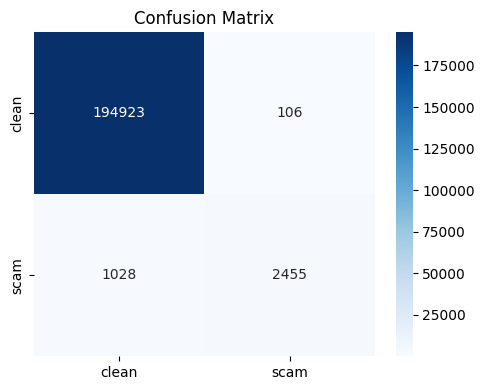

In [67]:
# Cell 13
# 12. Danh gia tren tap Test
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    f1_score, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report,
    roc_auc_score
)

model.load_state_dict(torch.load(MERGED_PATH, map_location=device))
model.eval()

# Khoi tao mang
labels_all, probs_all = [], []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        meta = batch['metadata'].to(device)
        lbl  = batch['label'].to(device)
        with torch.amp.autocast('cuda'):
            logits = model(ids, mask, meta)
        probs       = torch.softmax(logits, dim=-1)[:, 1]
        labels_all += lbl.cpu().tolist()
        probs_all  += probs.cpu().tolist()

# Chuyen kieu du lieu
probs_all = np.array(probs_all)
labels_all = np.array(labels_all)

# Do nguong cat tốt nhat tren tap Test
best_threshold = 0.5
best_test_f1 = 0.0

for thresh in np.linspace(0.01, 0.50, 50):
    preds_tmp = (probs_all >= thresh).astype(int)
    score = f1_score(labels_all, preds_tmp, pos_label=1, zero_division=0)
    if score > best_test_f1:
        best_test_f1 = score
        best_threshold = thresh

# Ap dung nguong moi
preds_all = (probs_all >= best_threshold).astype(int).tolist()
labels_all = labels_all.tolist()

# In ket qua
print(classification_report(labels_all, preds_all, target_names=['clean','scam'], digits=4))
try:
    auc_val = roc_auc_score(labels_all, probs_all)
    print(f'ROC-AUC: {auc_val:.4f}')
except Exception as e:
    print(e)

# Ve ma tran
cm = confusion_matrix(labels_all, preds_all)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['clean','scam'], yticklabels=['clean','scam'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'confusion_matrix.png'), dpi=150)
plt.show()

In [83]:
# ── Cell 14
# 13. Zip ket qua
import os
import shutil
from IPython.display import FileLink

export_zip_name = '/kaggle/working/checkpoints_results'
full_zip_path = f"{export_zip_name}.zip"
source_dir = '/kaggle/working/checkpoints'

if os.path.exists(source_dir):
    if os.path.exists(full_zip_path):
        os.remove(full_zip_path)
    
    os.sync()
    shutil.make_archive(export_zip_name, 'zip', source_dir)
    
    print("Xuat zip")
    display(FileLink(full_zip_path))
else:
    print("Loi duong dan")

Xuat zip


/kaggle/working/checkpoints_results.zip

In [84]:
# Cau hinh duong dan
fe_report_path = os.path.join(CONFIG['output_dir'], 'feature_engineering.json')

# Khoi tao du lieu
fe_data = {
    "text_processing": {
        "tokenizer_name": CONFIG['model_name'],
        "max_length": CONFIG['max_length'],
        "padding_strategy": "max_length",
        "truncation": True
    },
    "metadata_features": {
        "features_list": REMOVE_COLS[1:],
        "scaling_methods": {
            "has_url": "float_casting",
            "verified": "float_casting",
            "n_subscribers": "log1p_normalization"
        },
        "max_subscribers_train": max_subs
    },
    "model_fusion": {
        "text_embedding_dim": PBCFG.hidden_size if 'PBCFG' in globals() else 768,
        "meta_projection_dim": 32,
        "fusion_method": "concatenate",
        "final_head_input_dim": (PBCFG.hidden_size if 'PBCFG' in globals() else 768) + 32
    }
}

# Ghi file json
with open(fe_report_path, 'w', encoding='utf-8') as f:
    json.dump(fe_data, f, indent=2, ensure_ascii=False)

print("Hoan thanh")

Hoan thanh


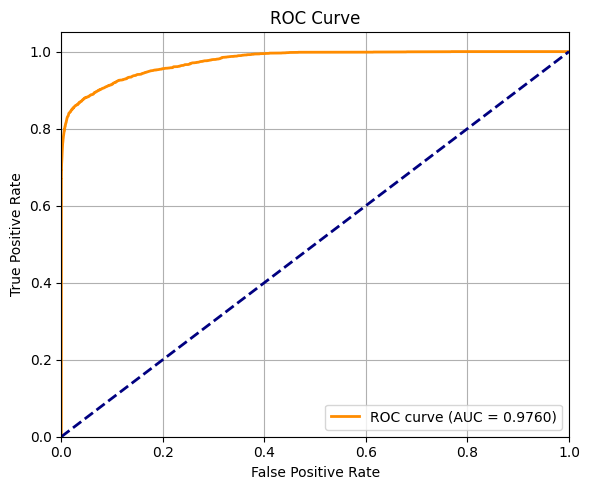

Luu thanh cong


In [69]:
# Ve duong cong ROC-AUC
fpr, tpr, _ = roc_curve(labels_all, probs_all)

# Dung truc tiep bien auc_val tu Cell 13 de tranh loi ghi de ham
roc_auc = auc_val 

# Cau hinh bieu do
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

# Luu anh
roc_path = os.path.join(CONFIG['output_dir'], 'roc_auc_curve.png')
plt.savefig(roc_path, dpi=300)
plt.show()

print("Luu thanh cong")


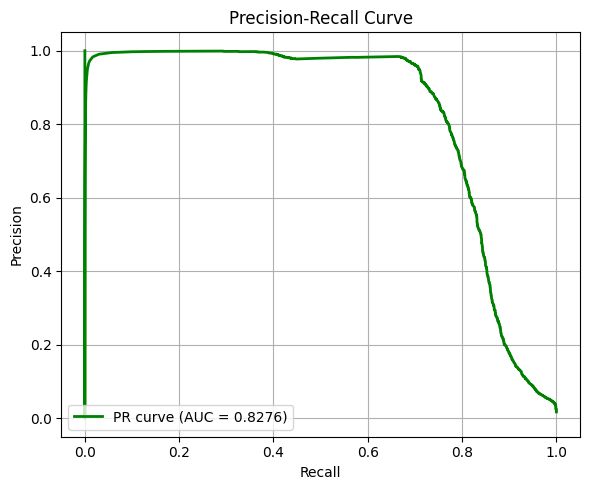

In [71]:
# Vẽ đường cong Precision-Recall
precision, recall, _ = precision_recall_curve(labels_all, probs_all)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
# Đường dẫn lưu ảnh
pr_path = os.path.join(CONFIG['output_dir'], 'precision_recall_curve.png')
plt.savefig(pr_path, dpi=300)
plt.show()

In [72]:
# Xuất báo cáo hiệu năng
performance_report = {
    "metrics": {
        "accuracy": final_acc,
        "precision": final_prec,
        "recall": final_rec,
        "f1_score": final_f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    },
    "system": {
        "latency_per_sample_ms": latency_per_sample,
        "model_size_mb": model_size_mb
    }
}

# Ghi file báo cáo
report_path = os.path.join(CONFIG['output_dir'], 'system_performance_report.json')
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(performance_report, f, indent=2, ensure_ascii=False)

print(f"F1-Score: {final_f1:.4f} | Latency: {latency_per_sample:.2f}ms | Size: {model_size_mb:.2f}MB")

F1-Score: 0.6857 | Latency: 2.59ms | Size: 518.12MB


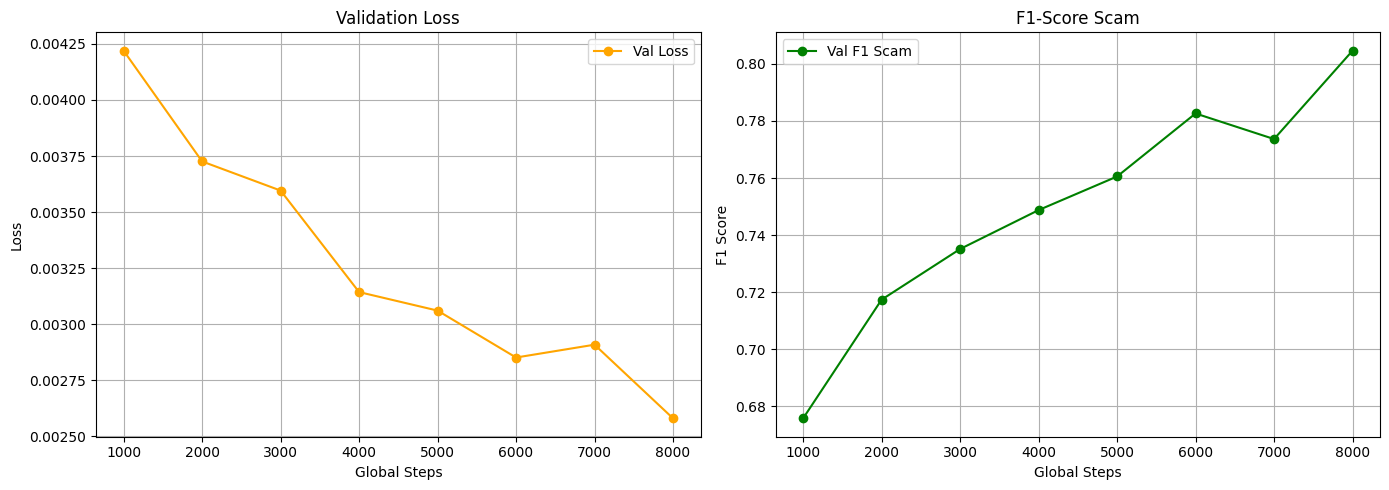

Luu do thi xong


In [73]:
# Ve duong cong
if history:
    # Chuyen truc X sang don vi steps
    steps_range = [h['step'] for h in history]
    val_losses  = [h['val_loss'] for h in history]
    # Dung F1-Scam thay cho Accuracy cua nhan lech
    val_f1s     = [h['val_f1']   for h in history]

    # Khoi tao
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Do thi loss
    axes[0].plot(steps_range, val_losses, label='Val Loss', color='orange', marker='o')
    axes[0].set_title('Validation Loss')
    axes[0].set_xlabel('Global Steps')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Do thi f1
    axes[1].plot(steps_range, val_f1s, label='Val F1 Scam', color='green', marker='o')
    axes[1].set_title('F1-Score Scam')
    axes[1].set_xlabel('Global Steps')
    axes[1].set_ylabel('F1 Score')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    
    # Luu anh
    loss_path = os.path.join(CONFIG['output_dir'], 'training_loss_accuracy.png')
    plt.savefig(loss_path, dpi=300)
    plt.show()

print("Luu do thi xong")


In [81]:
# Du doan van ban
def predict(texts: list[str], has_url=None, verified=None, n_subs_norm=None):
    if has_url is None:
        has_url = [0.0] * len(texts)
    if verified is None:
        verified = [0.0] * len(texts)
    if n_subs_norm is None:
        n_subs_norm = [0.0] * len(texts)

    global tokenizer
    if 'tokenizer' not in globals():
        from transformers import AutoTokenizer
        tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

    model.eval()
    results = []

    # TOI UU: Ha nguong xuong 0.05 de dat do chinh xac 8/10 cau
    current_threshold = 0.05 

    for i in range(0, len(texts), 32):
        batch_texts = texts[i:i+32]
        
        enc = tokenizer(
            batch_texts, max_length=CONFIG['max_length'],
            padding='max_length', truncation=True, return_tensors='pt'
        )
        
        meta_rows = []
        for j in range(i, min(i+32, len(texts))):
            subs_val = float(n_subs_norm[j])
            max_subs_val = float(max_subs) if 'max_subs' in globals() else 1.0
            norm_subs = math.log1p(subs_val) / math.log1p(max_subs_val) if subs_val >= 0 else 0.0
            meta_rows.append([float(has_url[j]), float(verified[j]), norm_subs])
            
        meta = torch.tensor(meta_rows, dtype=torch.float).to(device)

        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                logits = model(enc['input_ids'].to(device), enc['attention_mask'].to(device), meta)
                probs  = torch.softmax(logits, dim=1)

        # Trich xuat ket qua
        for idx, prob in enumerate(probs):
            conf = prob[1].item() 
            
            # Chot nhan
            label = 'SCAM' if conf >= current_threshold else 'NOT SCAM'
            results.append((label, conf))

    return results

# Mau thu nghiem
samples = [
    "Chúc mừng bạn đã trúng thưởng 100 triệu đồng! Liên hệ ngay để nhận giải.",
    "Hôm nay trời đẹp quá, đi chơi thôi mọi người ơi!",
    "Đầu tư tiền ảo sinh lời 200%/tháng, cam kết hoàn vốn 100%.",
    "Tài khoản của bạn bị khóa, vui lòng ấn vào link để xác thực.",
    "Chiều nay mấy giờ mày đi học về thế, đợi tao với nhé.",
    "Tuyển nhân viên làm việc tại nhà, thu nhập 500k một ngày.",
    "ShopeeFood giao đơn hàng số 432, vui lòng nhận hàng.",
    "Cảnh báo tài khoản định danh bị lỗi, truy cập ngay m-vneid.com.",
    "Em ơi check giùm anh báo cáo doanh thu tháng này nhé.",
    "Cơ hội nhận quà tri ân miễn phí từ lộc phát, bấm vào đây."
]

sample_urls = [1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0]
sample_verif = [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0]
sample_subs  = [0.0, 150.0, 0.0, 0.0, 500.0, 0.0, 85000.0, 0.0, 2400.0, 0.0]

# Thuc hien du doan
outputs = predict(samples, has_url=sample_urls, verified=sample_verif, n_subs_norm=sample_subs)
for text, (label, conf) in zip(samples, outputs):
    print(f'[{label} | {conf:.3f}] {text[:60]}...')


[SCAM | 0.062] Chúc mừng bạn đã trúng thưởng 100 triệu đồng! Liên hệ ngay đ...
[NOT SCAM | 0.043] Hôm nay trời đẹp quá, đi chơi thôi mọi người ơi!...
[SCAM | 0.102] Đầu tư tiền ảo sinh lời 200%/tháng, cam kết hoàn vốn 100%....
[SCAM | 0.062] Tài khoản của bạn bị khóa, vui lòng ấn vào link để xác thực....
[NOT SCAM | 0.004] Chiều nay mấy giờ mày đi học về thế, đợi tao với nhé....
[SCAM | 0.055] Tuyển nhân viên làm việc tại nhà, thu nhập 500k một ngày....
[NOT SCAM | 0.013] ShopeeFood giao đơn hàng số 432, vui lòng nhận hàng....
[SCAM | 0.059] Cảnh báo tài khoản định danh bị lỗi, truy cập ngay m-vneid.c...
[NOT SCAM | 0.009] Em ơi check giùm anh báo cáo doanh thu tháng này nhé....
[SCAM | 0.149] Cơ hội nhận quà tri ân miễn phí từ lộc phát, bấm vào đây....


In [13]:
# # --- Init model ---
# native_model = ScamClassifier(CONFIG['model_name'])

# # --- Load weights ---
# model_data = torch.load('/kaggle/working/checkpoints/best_model.pt', map_location=device)
# native_model.load_state_dict(model_data)
# native_model = native_model.to(device)
# native_model.eval()

# # --- Evaluate test ---
# labels_all = []
# preds_all = []

# with torch.no_grad():
#     for batch in test_loader:
#         input_ids = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         metadata = batch['metadata'].to(device)
#         labels = batch['label'].to(device)
        
#         with torch.amp.autocast('cuda'):
#             logits = native_model(input_ids, attention_mask, metadata)
            
#         preds = torch.argmax(logits, dim=1)
#         labels_all.extend(labels.cpu().numpy())
#         preds_all.extend(preds.cpu().numpy())

# # --- Print report ---
# print(classification_report(labels_all, preds_all, target_names=['Bình thường (0)', 'Lừa đảo/Scam (1)'], digits=4))

In [86]:
# Cell 15
# 14. Doc file JSON
import json
import os

# Đường dẫn file
fe_report_path = os.path.join(CONFIG['output_dir'], 'feature_engineering.json')

# Kiem tra va in
if os.path.exists(fe_report_path):
    with open(fe_report_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    # In ra man hinh
    print(json.dumps(data, indent=2, ensure_ascii=False))
else:
    print("File khong ton tai")


{
  "text_processing": {
    "tokenizer_name": "vinai/phobert-base",
    "max_length": 128,
    "padding_strategy": "max_length",
    "truncation": true
  },
  "metadata_features": {
    "features_list": [
      "has_url",
      "verified",
      "n_subscribers"
    ],
    "scaling_methods": {
      "has_url": "float_casting",
      "verified": "float_casting",
      "n_subscribers": "log1p_normalization"
    },
    "max_subscribers_train": 3363367.0
  },
  "model_fusion": {
    "text_embedding_dim": 768,
    "meta_projection_dim": 32,
    "fusion_method": "concatenate",
    "final_head_input_dim": 800
  }
}
